# 📊 Exploratory Data Analysis (EDA) — Proyek SIDIAS
Notebook ini digunakan untuk mengeksplorasi, memvisualisasikan, dan memvalidasi tiga pilar data utama pada sistem SIDIAS:
1. **Data Tabular (Kaggle)**: Menemukan tren, korelasi fitur, dan karakteristik gizi balita.
2. **Data Citra (Roboflow)**: Memverifikasi sebaran jumlah file dan kesiapan data gambar untuk CNN.
3. **Validasi Z-Score (WHO)**: Menguji akurasi engine kalkulator Z-score berbasis referensi master WHO.

## Sentralisasi Library & Konfigurasi Global
Cell ini menyatukan semua library di bagian paling atas sesuai aturan coding best-practice agar notebook terlihat bersih.

In [32]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from scipy import stats

# Mengabaikan pesan warning agar output notebook tetap rapi
warnings.filterwarnings('ignore')
    

# Set tema visualisasi agar tampak dark-elegant dan sinematik
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Definisikan path data secara terpusat
DATA_TABULAR_PATH = '../data/processed/dataset_stunting_clean.csv'
DATA_MASTER_WHO_PATH = 'data_science/data/raw/who_source/who_reference_master.csv'
DATA_GAMBAR_PATH = '../data/processed/gambar'


# Daftarkan folder root agar file zscore_calculator.py bisa di-import langsung
sys.path.append('../')

print("✅ Kumpulan library dan konfigurasi path berhasil dimuat!")

✅ Kumpulan library dan konfigurasi path berhasil dimuat!


## 📁 Part 1: Exploratory Data Tabular (Dataset Jurnal)
Pada tahap ini, memuat data 40.066 balita yang telah dibersihkan pada tahap *Data Wrangling*. Disini akan menganalisis karakteristik fisik balita serta melihat bagaimana distribusi kelas target `status_tb_u`.

## Load Data & Melihat Struktur Awal

In [33]:
# Membaca dataset hasil wrangling
df_kaggle = pd.read_csv(DATA_TABULAR_PATH)

# Menampilkan informasi dimensi dan tipe data
print(f"✅ Data Tabular Sukses Dimuat: {df_kaggle.shape[0]} baris, {df_kaggle.shape[1]} kolom\n")
print("--- Informasi Struktur Data ---")
print(df_kaggle.info())

# Menampilkan 5 baris pertama data
df_kaggle.head()

✅ Data Tabular Sukses Dimuat: 40066 baris, 11 kolom

--- Informasi Struktur Data ---
<class 'pandas.DataFrame'>
RangeIndex: 40066 entries, 0 to 40065
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_anak        40066 non-null  int64  
 1   jenis_kelamin  40066 non-null  str    
 2   usia_bulan     40066 non-null  float64
 3   berat_badan    40066 non-null  float64
 4   tinggi_badan   40066 non-null  float64
 5   status_bb_u    40066 non-null  str    
 6   zscore_bb_u    40066 non-null  float64
 7   status_tb_u    40066 non-null  str    
 8   zscore_tb_u    40066 non-null  float64
 9   status_bb_tb   40066 non-null  str    
 10  zscore_bb_tb   40066 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 4.6 MB
None


,id_anak,jenis_kelamin,usia_bulan,berat_badan,tinggi_badan,status_bb_u,zscore_bb_u,status_tb_u,zscore_tb_u,status_bb_tb,zscore_bb_tb
0,1,Perempuan,54.0,13.2,97.5,Normal,-1.94,Stunting,-2.11,Normal,-0.95
1,2,Laki-laki,44.0,12.0,92.0,Normal,-1.92,Stunting,-2.22,Normal,-0.88
2,3,Laki-laki,57.0,14.0,97.0,Normal,-1.90,Stunting,-2.58,Normal,-0.48
3,4,Laki-laki,26.0,11.0,79.0,Normal,-1.15,Stunting,-3.11,Normal,0.68
4,5,Perempuan,59.0,14.6,98.0,Normal,-1.66,Stunting,-2.49,Normal,-0.18


## EDA Univariat - Distribusi Target Status Gizi (TB/U)

=== DISTRIBUSI KATEGORI STATUS GIZI (TB/U) ===
- Tidak Stunting: 23866 balita (59.57%)
- Stunting: 16200 balita (40.43%)


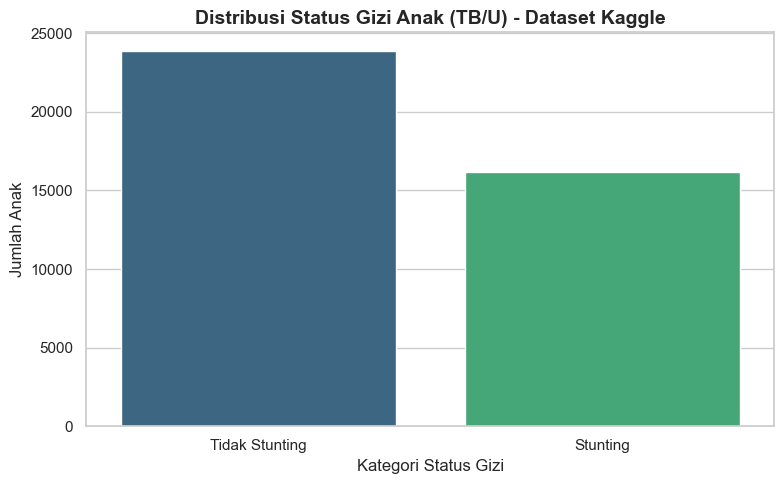

In [34]:
# Hitung nilai absolut dan persentase distribusi target
status_counts = df_kaggle['status_tb_u'].value_counts()
status_pct = df_kaggle['status_tb_u'].value_counts(normalize=True) * 100

print("=== DISTRIBUSI KATEGORI STATUS GIZI (TB/U) ===")
for idx in status_counts.index:
    print(f"- {idx}: {status_counts[idx]} balita ({status_pct[idx]:.2f}%)")

# Plotting grafik distribusi
plt.figure(figsize=(8, 5))
sns.countplot(data=df_kaggle, x='status_tb_u', palette='viridis', order=status_counts.index)
plt.title('Distribusi Status Gizi Anak (TB/U) - Dataset Kaggle', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Status Gizi', fontsize=12)
plt.ylabel('Jumlah Anak', fontsize=12)
plt.tight_layout()
plt.show()

## EDA Bivariat - Hubungan Usia dan Kerentanan Stunting

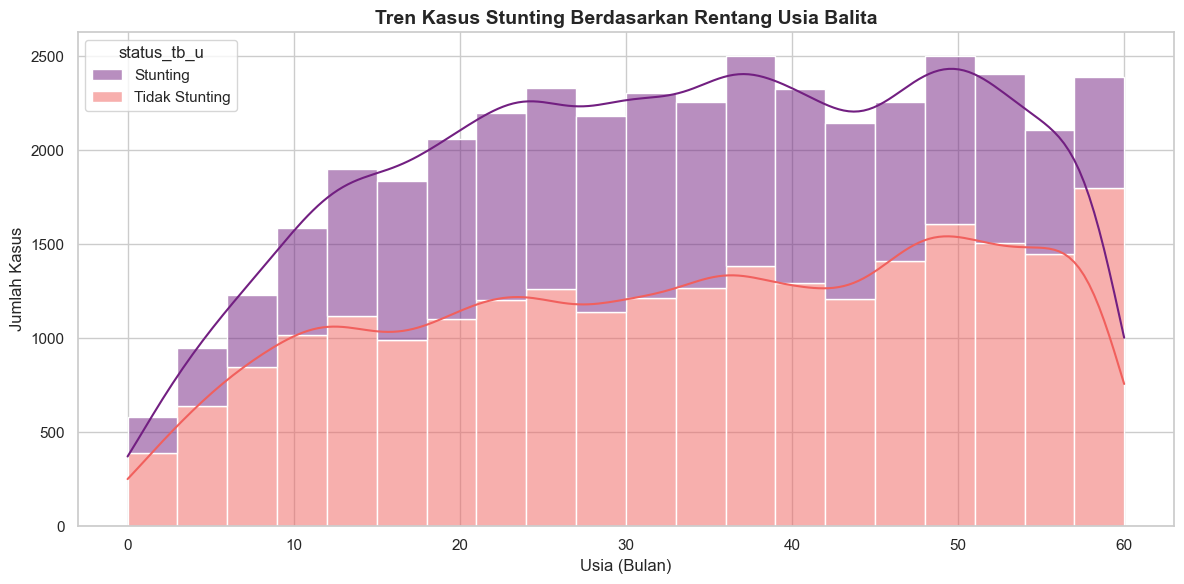

In [35]:
# Visualisasi histogram berlapis untuk melihat pada rentang usia berapa stunting sering terjadi
plt.figure(figsize=(12, 6))
sns.histplot(data=df_kaggle, x='usia_bulan', hue='status_tb_u', multiple='stack', kde=True, palette='magma', bins=20)
plt.title('Tren Kasus Stunting Berdasarkan Rentang Usia Balita', fontsize=14, fontweight='bold')
plt.xlabel('Usia (Bulan)', fontsize=12)
plt.ylabel('Jumlah Kasus', fontsize=12)
plt.tight_layout()
plt.show()

## EDA Multivariat - Scatter Plot Karakteristik Antropometri

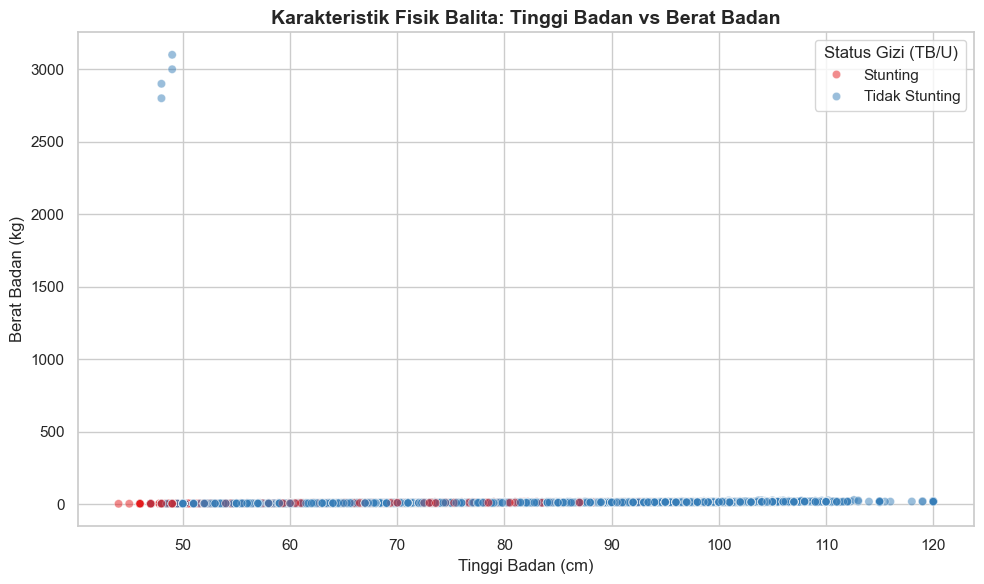

In [36]:
# Memetakan sebaran fisik anak stunting vs normal ketika variabel tinggi dan berat diadu
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_kaggle, x='tinggi_badan', y='berat_badan', hue='status_tb_u', alpha=0.5, palette='Set1')
plt.title('Karakteristik Fisik Balita: Tinggi Badan vs Berat Badan', fontsize=14, fontweight='bold')
plt.xlabel('Tinggi Badan (cm)', fontsize=12)
plt.ylabel('Berat Badan (kg)', fontsize=12)
plt.legend(title='Status Gizi (TB/U)')
plt.tight_layout()
plt.show()

## 🖼️ Part 2: Exploratory Data Citra (Roboflow Images)
Kecerdasan buatan visual (CNN) membutuhkan data gambar yang jelas dan seimbang. Pada bagian ini, melakukan audit volume data gambar di folder latihan (`train`) untuk memastikan sebaran kelas (`Healthy`, `MalNutrisi`, `Stunting`) siap dipakai untuk training.

## Bar Chart Volume Data Gambar per Kelas

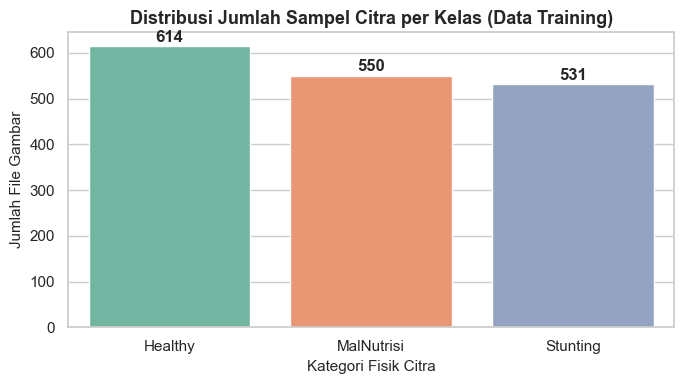

In [37]:
# Menghitung otomatis jumlah file gambar di dalam folder dataset
train_dir = os.path.join(DATA_GAMBAR_PATH, "train")
kelas_gambar = []
jumlah_gambar = []

if os.path.exists(train_dir):
    for label in os.listdir(train_dir):
        label_path = os.path.join(train_dir, label)
        if os.path.isdir(label_path):
            kelas_gambar.append(label)
            jumlah_gambar.append(len(os.listdir(label_path)))
            
    # Buat DataFrame report sementara
    df_img_report = pd.DataFrame({'Kelas': kelas_gambar, 'Jumlah': jumlah_gambar})
    
    # Plotting volume data gambar
    plt.figure(figsize=(7, 4))
    sns.barplot(data=df_img_report, x='Kelas', y='Jumlah', palette='Set2')
    plt.title('Distribusi Jumlah Sampel Citra per Kelas (Data Training)', fontsize=13, fontweight='bold')
    plt.xlabel('Kategori Fisik Citra', fontsize=11)
    plt.ylabel('Jumlah File Gambar', fontsize=11)
    
    # Memunculkan nilai angka tepat di atas bar grafik
    for index, value in enumerate(jumlah_gambar):
        plt.text(index, value + 10, str(value), ha='center', fontweight='bold')
        
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Warning: Folder '{train_dir}' belum tersedia. Pastikan ekstraksi dataset Roboflow pada file preprocessing telah sukses dieksekusi.")

## 🧮 Part 3: Validasi & Integrasi Rumus Z-Score WHO
Sebelum melepas sistem ke aplikasi web production Streamlit, wajib menguji fungsionalitas OOP dari class `StuntingCalculator` yang berada di file `zscore_calculator.py`. Langkah ini memastikan bahwa rumus matematis LMS WHO bekerja dengan presisi tinggi tanpa error data mismatch.

## Pengujian Objek StuntingCalculator secara Real-Time

In [43]:


# 1. Ambil jalur absolut dari posisi notebook saat ini
notebook_dir = Path(os.getcwd()).resolve()

# 2. Cari folder utama proyek (SIDIAS)
root_dir = None
for parent in [notebook_dir] + list(notebook_dir.parents):
    if (parent / "data_science").exists():
        root_dir = parent
        break

if root_dir is None:
    root_dir = notebook_dir.parent

# 3. Tentukan folder src tempat zscore_calculator.py berada secara absolut
src_dir = root_dir / 'data_science' / 'src'

# 4. Daftarkan folder src ke dalam sistem pencarian Python
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))


try:
    # Mengimport Class lokal dari src
    from zscore_calculator import StuntingCalculator
    print("✅ BERHASIL! Modul 'zscore_calculator' dikenali di Notebook EDA!")
    
    # Tentukan path master WHO secara absolut dari posisi root proyek
    absolute_who_path = root_dir / 'data_science' / 'data' / 'raw' / 'who_source' / 'who_reference_master.csv'
    
    # Inisialisasi kalkulator di notebook
    calc = StuntingCalculator(str(absolute_who_path))
    print("✅ Objek StuntingCalculator Berhasil Diinisialisasi di Notebook!")
    
    print("\n--- SIMULASI UJI KASUS DISKRETIK VIA NOTEBOOK ---")
    calc.detect_stunting(
        nama="Budi", 
        jenis_kelamin="Laki-laki", 
        usia_bulan=12, 
        tinggi_cm=68.5, 
        berat_kg=8.5
    )

except ModuleNotFoundError as e:
    print(f"❌ KENDALA: Python tidak bisa menemukan file 'zscore_calculator.py' di folder: {src_dir}")
except FileNotFoundError:
    print(f"⚠️ KENDALA: Modul aman, tetapi file master WHO tidak ada di: \n   {absolute_who_path}")
except Exception as e:
    print(f"❌ Terjadi kendala lain: {e}")

✅ BERHASIL! Modul 'zscore_calculator' dikenali di Notebook EDA!
✅ Objek StuntingCalculator Berhasil Diinisialisasi di Notebook!

--- SIMULASI UJI KASUS DISKRETIK VIA NOTEBOOK ---
--- Hasil Analisis Balita: Budi ---
Z-Score TB/U: -3.05
Status: Sangat Pendek (Severely Stunted)
Peringatan: Balita terdeteksi Stunting/Rentan. Disarankan konsultasi ahli gizi.


## 🏁 Kesimpulan Akhir Tahap EDA
Melalui serangkaian analisis data yang telah dilakukan pada tiga pilar utama (Data Tabular Jurnal, Data Citra Roboflow, dan Validasi Engine Z-Score WHO), seluruh komponen data untuk proyek SIDIAS dinyatakan lolos verifikasi awal. 

Hubungan statistik pada data antropometri terbukti logis, sebaran volume data gambar siap digunakan untuk kebutuhan latih model CNN, dan backend kalkulator medis berbasis referensi WHO telah berjalan dengan presisi tinggi. Seluruh arsitektur data ini siap diintegrasikan ke tahap pemodelan (*Machine Learning*) dan pengembangan aplikasi utama berbasis Streamlit.

## Otomatisasi Ekspor Laporan ke HTML

In [44]:
# =====================================================================
# --- OTOMATISASI EKSPOR LAPORAN EDA KE HTML ---
# =====================================================================
try:
    print("⏳ Sedang memproses kompilasi laporan EDA ke format HTML...")
    
    # Memastikan folder '../reports' ada, jika belum maka buat otomatis
    reports_dir = os.path.abspath(os.path.join('..', 'reports'))
    os.makedirs(reports_dir, exist_ok=True)
    
    # Menjalankan perintah ekspor menggunakan nbconvert bawaan jupyter via terminal command
    # Perintah ini akan mengonversi file EDA.ipynb saat ini ke folder reports
    os.system('jupyter nbconvert --to html EDA.ipynb --output-dir="../reports"')
    
    print("🏁 SUCCESS: Laporan 'EDA.html' telah berhasil diterbitkan di dalam folder /reports!")
    print(f"📁 Jalur File: {os.path.join(reports_dir, 'EDA.html')}")
except Exception as e:
    print(f"⚠️ Catatan: Ekspor HTML otomatis dilewati atau terjadi kendala: {e}")

⏳ Sedang memproses kompilasi laporan EDA ke format HTML...
🏁 SUCCESS: Laporan 'EDA.html' telah berhasil diterbitkan di dalam folder /reports!
📁 Jalur File: d:\Dicoding\capstone-project\SIDIAS-\data_science\reports\EDA.html
